In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

# Data review and Summary

In [3]:
df = pd.read_csv('superstore_eda.csv')

In [4]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10014 entries, 0 to 10013
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10014 non-null  int64  
 1   Order ID       10014 non-null  object 
 2   Order Date     10014 non-null  object 
 3   Ship Date      10014 non-null  object 
 4   Ship Mode      9916 non-null   object 
 5   Customer ID    10014 non-null  object 
 6   Customer Name  10014 non-null  object 
 7   Segment        10014 non-null  object 
 8   Country        10014 non-null  object 
 9   City           10014 non-null  object 
 10  State          10014 non-null  object 
 11  Postal Code    10014 non-null  int64  
 12  Region         10014 non-null  object 
 13  Product ID     10014 non-null  object 
 14  Category       10014 non-null  object 
 15  Sub-Category   10014 non-null  object 
 16  Product Name   10014 non-null  object 
 17  Sales Price    10014 non-null  float64
 18  Quanti

In [5]:
# Explore the first few rows to understand the structure of the data.
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [6]:
# unique values of each column

df['Segment'].unique()
df['City'].unique()
df['Region'].unique()
df['Category'].unique()
df['Sub-Category'].unique()
df['Product Name'].unique()
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee', 'TX',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'CA ', 'New Hampshire',
       'Maryland', 'District of Columbia', 'WA\\', 'NJ', 'Kansas',
       'Vermont', 'Maine', 'South Dakota', 'Idaho', 'North Dakota',
       'Wyoming', 'West Virginia', 'NY'], dtype=object)

In [7]:
# summary statistics
df.describe()

,Row ID,Postal Code,Sales Price,Quantity,Discount,Profit
count,10014.000000,10014.000000,10014.000000,9996.000000,10014.000000,10014.000000
mean,4997.523367,55205.131616,230.038424,3.792517,0.156240,28.708317
std,2888.981754,32066.711027,623.057359,2.231021,0.206392,234.154272
min,1.000000,1040.000000,-31.500000,1.000000,0.000000,-6599.978000
25%,2494.250000,23223.000000,17.280000,2.000000,0.000000,1.731375
50%,4997.500000,57103.000000,54.780000,3.000000,0.200000,8.666500
75%,7500.750000,90008.000000,209.970000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# 2. Handling Duplicates

In [10]:
rows_before = len(df)
order_ids_before = df['Order ID'].nunique()
rows_before
order_ids_before

5009

In [11]:
df.drop_duplicates(inplace= True)

In [12]:
rows_after = len(df)
order_ids_after = df['Order ID'].nunique()
rows_after
order_ids_after

5009

In [13]:
#Document the number of rows and distinct Order IDs affected by this operation
rows_removed = rows_before - rows_after
order_ids_removed = order_ids_before - order_ids_after

print(f"Rows removed: {rows_removed}")
print(f"Distinct Order IDs removed: {order_ids_removed}")

Rows removed: 17
Distinct Order IDs removed: 0


# Identifying and imputing missing values

In [14]:
df[df.isna().any(axis =1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
13,14,CA-2016-161389,05/12/16,10/12/16,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,98103,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.976,NaN,0.2,132.5922
15,16,US-2015-118983,22/11/15,26/11/15,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.544,NaN,0.8,-3.8160
19,20,CA-2014-143336,27/08/14,2014-9-1,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,...,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,NaN,0.2,16.0110
24,25,CA-2015-106320,25/09/15,30/09/15,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.630,NaN,0.0,240.2649
26,27,CA-2016-121755,16/01/16,20/01/16,Second Class,EH-13945,Eric Hoffmann,Consumer,United States,Los Angeles,...,90049,West,TEC-AC-10003027,Technology,Accessories,Imation�8GB Mini TravelDrive USB 2.0�Flash Drive,90.570,NaN,0.0,11.7741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9657,9658,CA-2014-156160,22/09/14,2014-9-29,NaN,AS-10090,Adam Shillingsburg,Consumer,United States,New York City,...,10035,East,OFF-AR-10003876,Office Supplies,Art,Avery Hi-Liter GlideStik Fluorescent Highlight...,13.040,4.0,0.0,5.7376
9658,9659,CA-2014-156160,22/09/14,2014-9-29,NaN,AS-10090,Adam Shillingsburg,Consumer,United States,New York City,...,10035,East,FUR-CH-10004983,Furniture,Chairs,Office Star - Mid Back Dual function Ergonomic...,579.528,4.0,0.1,83.7096
9871,9872,CA-2017-146269,06/10/17,06/10/17,NaN,MH-17455,Mark Hamilton,Consumer,United States,Chicago,...,60623,Central,OFF-ST-10003208,Office Supplies,Storage,Adjustable Depth Letter/Legal Cart,290.336,2.0,0.2,32.6628
9872,9873,CA-2017-146269,06/10/17,06/10/17,NaN,MH-17455,Mark Hamilton,Consumer,United States,Chicago,...,60623,Central,OFF-AR-10004790,Office Supplies,Art,Staples in misc. colors,19.152,2.0,0.2,1.1970


In [15]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode        98
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales Price       0
Quantity         18
Discount          0
Profit            0
dtype: int64

In [16]:
# Data type conversion of date time
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

C:\Users\tjtar\AppData\Local\Temp\ipykernel_17940\2336779670.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
C:\Users\tjtar\AppData\Local\Temp\ipykernel_17940\2336779670.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [17]:
df['days to ship'] = (df['Ship Date'] - df['Order Date']).dt.days

In [18]:
rows_before = df.shape[0]
order_ids_before = df['Order ID'].nunique()

In [19]:
df.loc[(df['Ship Mode'].isnull()) & (df['days to ship'] == 0), 'Ship Mode'] = 'Same Day'
df.loc[(df['Ship Mode'].isnull()) & (df['days to ship'] == 7), 'Ship Mode'] = 'Standard Class'

In [20]:
median_qty = df['Quantity'].median()
df['Quantity'].fillna(median_qty, inplace=True)

C:\Users\tjtar\AppData\Local\Temp\ipykernel_17940\2119011539.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(median_qty, inplace=True)


In [21]:
df['Ship Mode'].str.strip()

0          Second Class
1          Second Class
2          Second Class
3        Standard Class
4        Standard Class
              ...      
9992     Standard Class
9993       Second Class
9998       Second Class
10000       First Class
10005       First Class
Name: Ship Mode, Length: 9997, dtype: object

In [22]:
df['Ship Mode'].fillna('Standard Class', inplace=True)

In [23]:
rows_after = df.shape[0]
order_ids_after = df['Order ID'].nunique()
print("Rows affected:", rows_before - rows_after)
print("Order IDs affected:", order_ids_before - order_ids_after)

Rows affected: 0
Order IDs affected: 0


# Data Masking and String Handling

In [24]:
df['Customer Name Masked'] = df['Customer Name'].apply(lambda x: '.'.join([n[0] for n in x.split()]) + '.')

In [25]:
df.drop('Customer Name', axis=1, inplace=True)

In [26]:
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

# Handling inconsistent categorical Data

In [27]:
state_map = {'CA': 'California', 'NY': 'New York', 'TX' : 'Texas', 'NJ': 'New Jersey', 'WA\\': 'Washington', 'CA ': 'California'}

In [28]:
df['State'] = df['State'].map(lambda x: state_map.get(x, x))

In [29]:
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

# Feature Engineering: Create new columns

In [30]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,days to ship,Customer Name Masked
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4.0,0.0,13.3200,5,D.B.
9993,9994,CA-2017-119914,2017-04-05,2017-09-05,Second Class,CC-12220,Consumer,United States,Westminster,California,...,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2.0,0.0,72.9480,153,C.C.
9998,20,CA-2014-143336,2014-08-27,2014-09-01,Second Class,ZD-21925,Consumer,United States,San Francisco,California,...,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,3.0,0.2,16.0110,5,Z.D.
10000,8852,CA-2015-140718,2015-02-07,2015-04-07,First Class,FA-14230,Corporate,United States,Raleigh,North Carolina,...,OFF-PA-10002250,Office Supplies,Paper,Things To Do Today Pad,-9.392,2.0,0.2,3.2872,59,F.A.
10005,1044,CA-2017-115651,2017-09-07,2017-12-07,First Class,NS-18640,Corporate,United States,Chicago,Illinois,...,OFF-AR-10001130,Office Supplies,Art,"Quartet Alpha White Chalk, 12/Pack",-8.840,5.0,0.2,2.9835,91,N.S.


In [83]:
# Original Price: The price before any discount is applied.
df['Orignal price'] = df['Sales Price'] / (1 - df['Discount'])

In [84]:
# Total Sales: The total revenue generated by multiplying the Sales Price by Quantity.
df['Total Sales'] = df['Sales Price'] * df['Quantity']

In [85]:
# Total Profit: The total profit earned by multiplying the Profit by Quantity.
df['Total Profit'] = df['Quantity'] * df['Profit']

In [86]:
# Discount Price: The amount of discount applied, calculated based on the Original Price and Discount.
df['Discount Price'] = df['Orignal price'] * df['Discount']

In [87]:
# Total Discount: The total discount value for the quantity sold.
df['Total Discount'] = df['Discount Price'] * df['Quantity']

In [64]:
#Create a new column Shipping Urgency based on Days to Ship:
def shipping_urgency(days):
    if days == 0:
        return "Immediate"
    elif 1 <= days <= 3:
        return "Urgent"
    else:
        return "Standard"

df['Shipping Urgency'] = df['days to ship'].apply(shipping_urgency)

In [65]:
#Create a column that calculates days since last order.
df = df.sort_values(['Customer ID', 'Order Date'])
df['Days Since Last Order'] = df.groupby('Customer ID')['Order Date'].diff().dt.days

In [66]:
# Create a new dataset which stores the total sales, quantity and discount per customer and then merge these back to the original dataset
customer_agg = df.groupby('Customer ID').agg({
    'Total Sales': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

customer_agg.rename(columns={
    'Total Sales': 'Customer Total Sales',
    'Quantity': 'Customer Total Quantity',
    'Discount': 'Customer Total Discount'
},inplace=True)

In [40]:
df = df.merge(customer_agg, on='Customer ID', how = 'left')

# Outlier Detection and Handling: Identify and handle outliers in the Sales Price column

In [41]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Orignal price,Total Sales,Total Profit,Discount Price,Total Discount,Shipping Urgency,Days Since Last Order,Customer Total Sales,Customer Total Quantity,Customer Total Discount
0,2230,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,841.96,1347.136,505.1760,168.392,336.784,Standard,NaN,16073.344,30.0,0.090909
1,2231,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,52.98,105.960,29.6688,0.000,0.000,Standard,0.0,16073.344,30.0,0.090909
2,7469,CA-2014-138100,2014-09-15,2014-09-20,Standard Class,AA-10315,Consumer,United States,New York City,New York,...,14.94,44.820,21.0654,0.000,0.000,Standard,168.0,16073.344,30.0,0.090909
3,7470,CA-2014-138100,2014-09-15,2014-09-20,Standard Class,AA-10315,Consumer,United States,New York City,New York,...,14.56,29.120,12.5216,0.000,0.000,Standard,0.0,16073.344,30.0,0.090909
4,1300,CA-2015-121391,2015-04-10,2015-07-10,First Class,AA-10315,Consumer,United States,San Francisco,California,...,26.96,53.920,14.0192,0.000,0.000,Standard,207.0,16073.344,30.0,0.090909


In [42]:
q1 = df['Sales Price'].quantile(0.25)
q3 = df['Sales Price'].quantile(0.75)

IQR = q3 - q1

In [43]:
lower_bound = q1 - 3*IQR
upper_bound = q3 + 3*IQR

In [44]:
df = df[(df['Sales Price'] >= lower_bound) & (df['Sales Price'] <= upper_bound)]

# Customer Segmentation and Analysis

In [45]:
# Calculate Customer Sales Quintile and Customer Profit Quintile based on total sales and total profit per Customer ID.

customer_stats = df.groupby('Customer ID').agg({
    'Total Sales': 'sum',
    'Total Profit': 'sum'
}).reset_index()

In [46]:
customer_stats['Sales Quintile'] = pd.qcut(customer_stats['Total Sales'],5, labels = [1,2,3,4,5])
customer_stats['Profit Quintile'] = pd.qcut(customer_stats['Total Profit'],5, labels = [1,2,3,4,5])

In [47]:
df = df.merge(customer_stats[['Customer ID', 'Sales Quintile', 'Profit Quintile']], on='Customer ID', how='left')

In [48]:
# Create a cross-grid (cross-tabulation) based on these two quintiles to analyze 
# the relationship between customer sales and profitability.
cross_grid = pd.crosstab(
    customer_stats['Sales Quintile'],
    customer_stats['Profit Quintile'],
    rownames=['Sales Quintile'],
    colnames=['Profit Quintile']
)
cross_grid

Profit Quintile,1,2,3,4,5
Sales Quintile,,,,,
1,39,87,32,1,0
2,31,34,63,30,0
3,23,19,32,59,25
4,34,10,19,43,52
5,32,8,12,25,82


# Final Analysis & Dashboard creation: 1 Sales & Profit Analysis

C:\Users\tjtar\AppData\Local\Temp\ipykernel_17940\2670276201.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


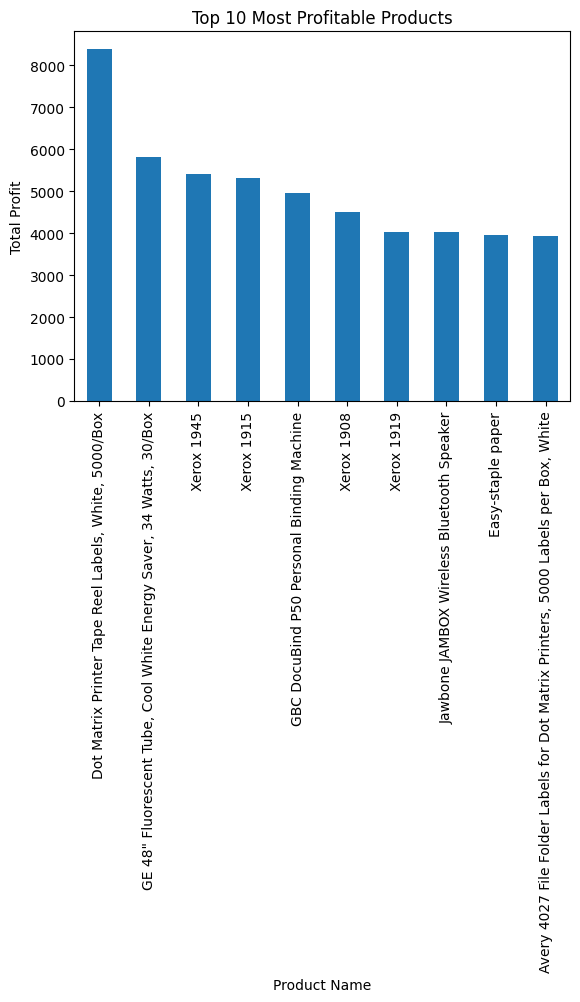

In [49]:
#1 Top 10 Most Profitable Products 
top_profit = df.groupby('Product Name')['Total Profit'].sum().nlargest(10)

top_profit.plot(kind='bar')

plt.title('Top 10 Most Profitable Products')
plt.xlabel('Product Name')
plt.ylabel('Total Profit')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

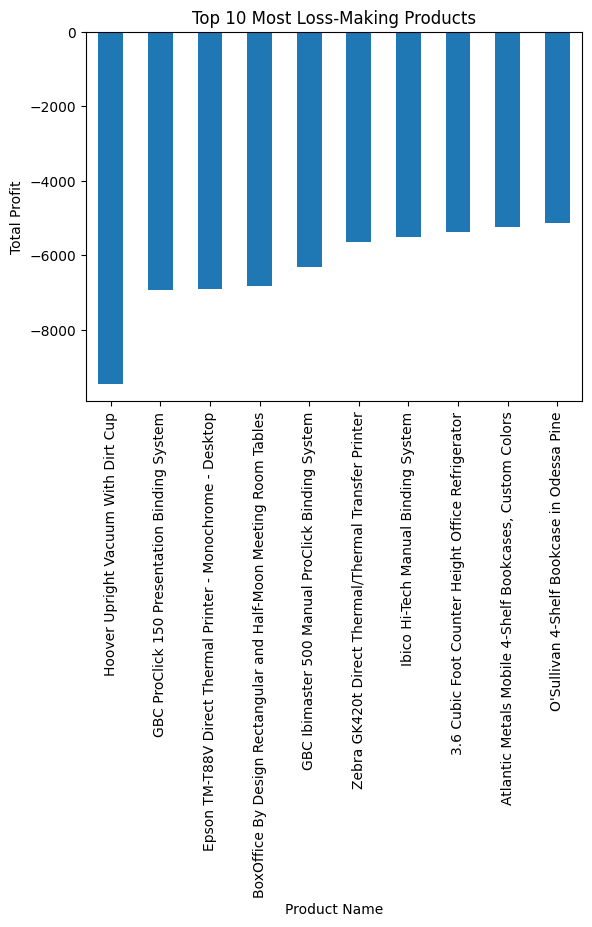

In [50]:
#2 Top 10 Most Loss-Making Products

top_loss = df.groupby('Product Name')['Total Profit'].sum().nsmallest(10)

top_loss.plot(kind='bar')

plt.title('Top 10 Most Loss-Making Products')
plt.xlabel('Product Name')
plt.ylabel('Total Profit')

plt.xticks(rotation=90)
plt.show()

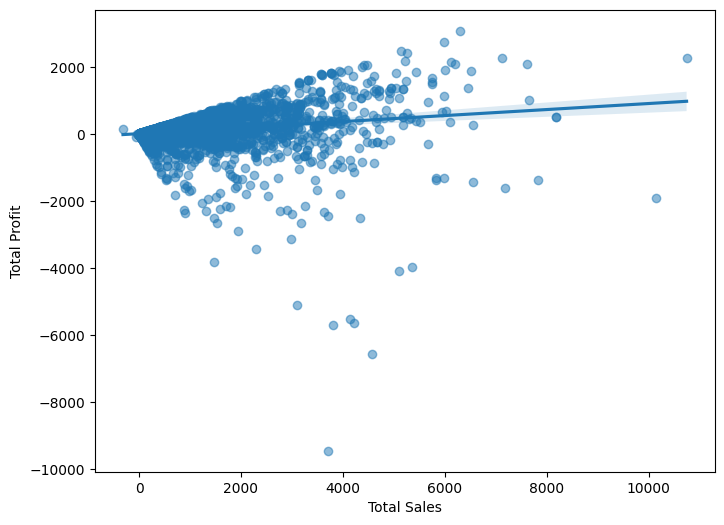

In [51]:
#3 Sales vs. Profit Correlation 

plt.figure(figsize=(8,6))

sns.regplot(
    data =df,
    x='Total Sales',
    y='Total Profit',
    scatter_kws={'alpha':0.5}
)
plt.title = 'Sales vs. Profit Correlation'
plt.xlabel = ('Total Sales')
plt.ylabel = ('Total Profit')
plt.show()

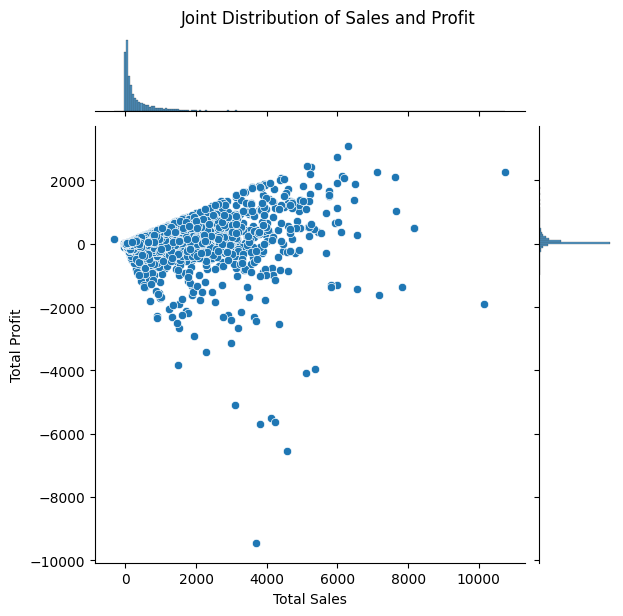

In [52]:
#4 Joint Distribution of Sales and Profit

sns.jointplot(
    data=df,
    x='Total Sales',
    y='Total Profit',
    kind='scatter'
)
plt.suptitle('Joint Distribution of Sales and Profit', y=1.02)
plt.show()

# 2 Customer Segmentation and Analysis

In [53]:
# Customer Sales Quintile vs. Customer Profit Quintil
heatmap_data = pd.crosstab(
    customer_stats['Sales Quintile'],
    customer_stats['Profit Quintile']
)

In [54]:
import matplotlib.pyplot as plt

TypeError: 'str' object is not callable

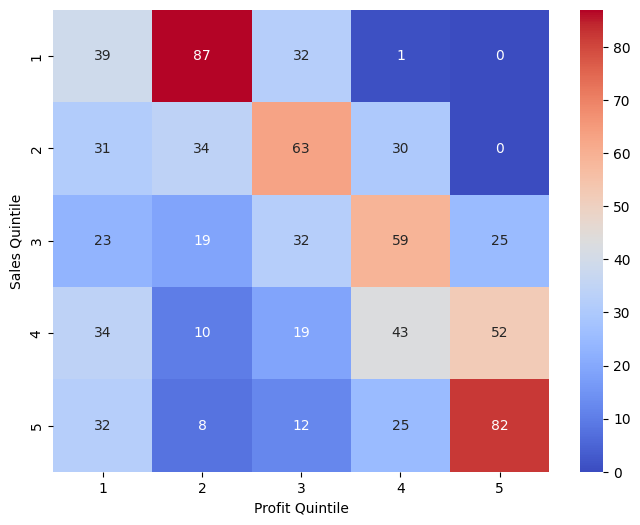

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)
plt.title('Customer Sales Quintile vs Profit Quintile')
plt.xlabel('Profit Quintile')
plt.ylabel('Sales Quintile')

plt.show()

In [60]:
# Product Category Performance Across Segments
pivot = df.pivot_table(
    index='Category',
    columns='Segment',
    values=['Total Sales', 'Total Profit'],
    aggfunc='sum'
)
# To highlight most/least profitable, sort by Total Profit
sorted_pivot = pivot['Total Profit'].sort_values(by=list(pivot['Total Profit'].columns), ascending=False)
sorted_pivot

Segment,Consumer,Corporate,Home Office
Category,,,
Office Supplies,161472.2012,108340.3423,76934.5485
Technology,106843.1819,50733.1806,32884.4565
Furniture,4052.6569,-5933.9168,-526.7924


# 3 Shipping and Delivery Analysis

TypeError: 'str' object is not callable

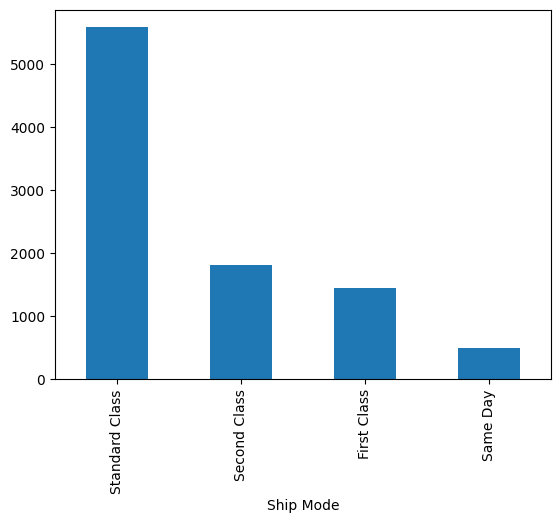

In [62]:
#Distribution of Shipping Urgency

import matplotlib.pyplot as plt

shipping_counts = df['Ship Mode'].value_counts()

shipping_counts.plot(kind='bar')

plt.title('Distribution of Shipping Urgency')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.show()

TypeError: 'str' object is not callable

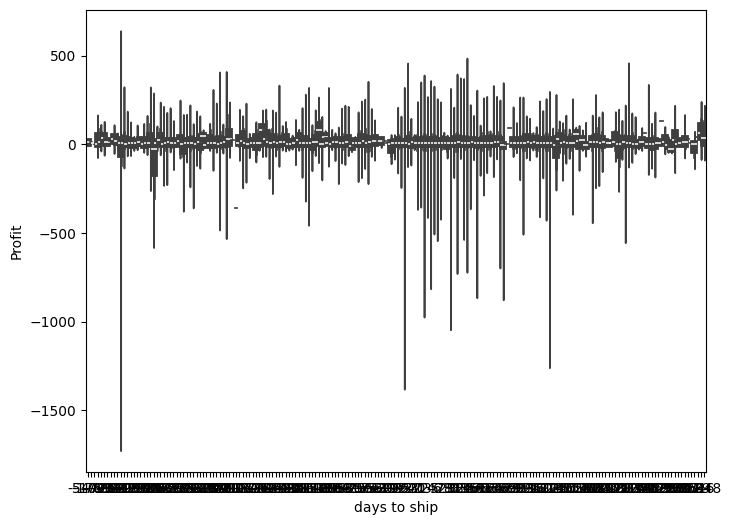

In [68]:
# Days to Ship vs Profit
import seaborn as sns

plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x='days to ship',
    y='Profit'
)

plt.title('Days to Ship vs Profit')
plt.show()

TypeError: 'str' object is not callable

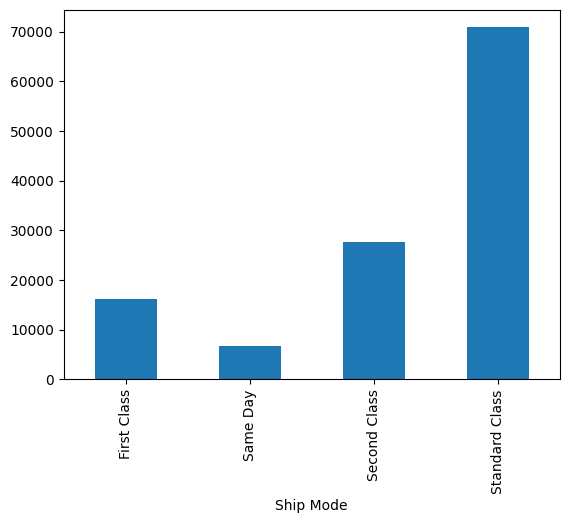

In [69]:
# Shipping Mode vs Profitability

ship_profit = df.groupby('Ship Mode')['Profit'].sum()

ship_profit.plot(kind='bar')

plt.title('Shipping Mode vs Profitability')
plt.xlabel('Ship Mode')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)
plt.show()

In [72]:
# Shipping Modes by Region

pivot_shipping = df.pivot_table(
    values=['Order ID', 'Total Sales', 'Total Profit'],
    index='Region',
    columns='Ship Mode',
    aggfunc={
        'Order ID': 'count',
        'Total Sales': 'sum',
        'Total Profit': 'sum'
    }
)
pivot_shipping

Order ID                                      Total Profit  \
Ship Mode First Class Same Day Second Class Standard Class  First Class   
Region                                                                    
Central           283      115          436           1353     394.5066   
East              455      137          494           1562   21950.2402   
South             219       78          300            911   16077.1626   
West              483      169          582           1752   23741.0491   

                                                   Total Sales             \
Ship Mode    Same Day Second Class Standard Class  First Class   Same Day   
Region                                                                      
Central     3234.0230    8371.0332     -2857.5172  131171.8040  49495.856   
East        7019.1758   25494.5343    104721.5065  209504.8110  67024.471   
South       7933.4040   34050.1345     78352.9964  103459.9140  38692.503   
West       11673.3681   60498.3407    134145.9009  247706.9135  79858.384   

                                       
Ship Mode Second Class Standard Class  
Region                                 
Central    233940.0800     658172.199  
East       252083.5110     758413.405  
South      164570.0975     462073.992  
West       323473.3055     945701.568

# 4 Regional Sales & Profitability

TypeError: 'str' object is not callable

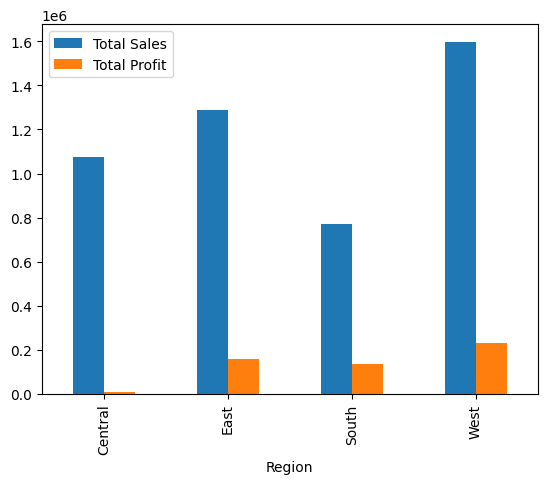

In [75]:
# Sales and Profit by Region

region_summary = df.groupby('Region')[['Total Sales', 'Total Profit']].sum()

region_summary.plot(kind='bar')

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')

plt.xticks(rotation=45)
plt.show()

In [76]:
# State-wise Profitability
state_profit = df.pivot_table(
    values='Profit',
    index='State',
    aggfunc='sum'
)
state_profit

,Profit
State,
Alabama,1743.6624
Arizona,-2135.8807
Arkansas,2711.9473
California,44672.2302
Colorado,-3438.5615
Connecticut,2460.9792
Delaware,3251.7385
District of Columbia,94.1444
Florida,-696.0981


              State_Code  Total Profit
State_Code      1.000000     -0.053552
Total Profit   -0.053552      1.000000


<Axes: >

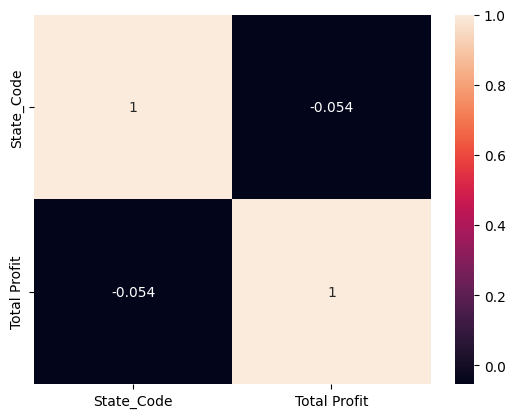

In [77]:
# Correlation between State and Profit
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['State_Code'] = le.fit_transform(df['State'])
corr = df[['State_Code', 'Total Profit']].corr()
print(corr)
sns.heatmap(corr, annot=True)

# 5 Discount and Pricing Analysis

TypeError: 'str' object is not callable

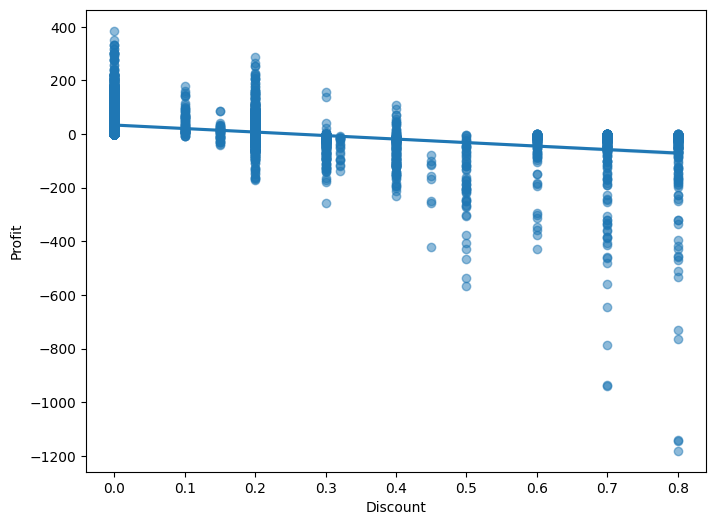

In [80]:
#Impact of Discounts on Profitability

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter_kws={'alpha':0.5}
)

plt.title('Impact of Discounts on Profitability')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

TypeError: 'str' object is not callable

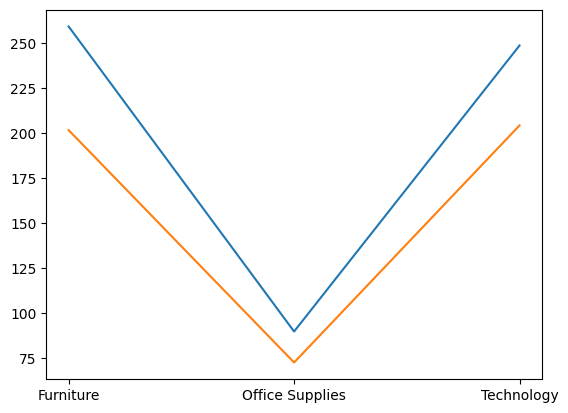

In [93]:
# Original Price vs Discounted Price

import matplotlib.pyplot as plt
category_prices = df.groupby('Category')[['Orignal price', 'Sales Price']].mean().reset_index()
plt.plot(category_prices['Category'], category_prices['Orignal price'], label='Orignal price')
plt.plot(category_prices['Category'], category_prices['Sales Price'], label='Discounted Price')
plt.xlabel('Category')
plt.ylabel('Price')
plt.title('Original vs. Discounted Price by Category')
plt.legend()
plt.show()

<Axes: title={'center': 'Order Frequency by Month'}, xlabel='Month'>

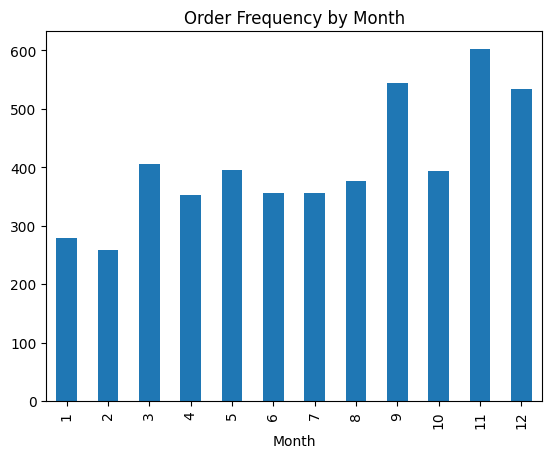

In [97]:
# Sales & Profit Trends Over Time

df['Month'] = df['Order Date'].dt.month
orders_per_month = df.groupby('Month')['Order ID'].nunique()
orders_per_month.plot(kind='bar', title='Order Frequency by Month')

<Axes: title={'center': 'Year-over-Year Growth in Sales and Profit'}, xlabel='Year'>

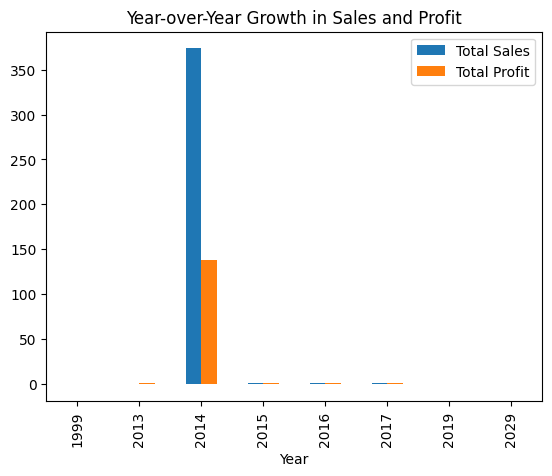

In [98]:
# Yearly Growth in Sales and Profit

df['Year'] = df['Order Date'].dt.year
yearly = df.groupby('Year')[['Total Sales', 'Total Profit']].sum()
yearly.pct_change().plot(kind='bar', title='Year-over-Year Growth in Sales and Profit')
